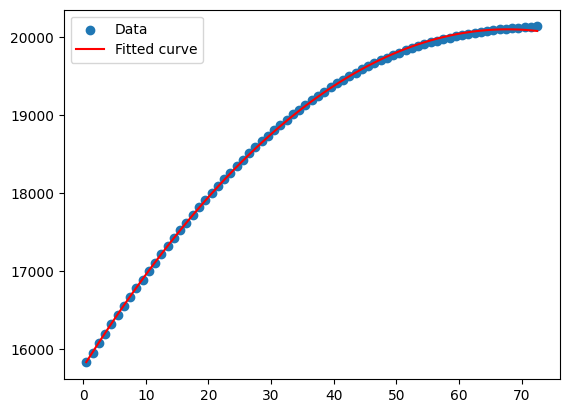

[-9.41448402e-01  1.27585019e+02  1.57726152e+04]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import csv

x_data = []
y_data = []

with open('Bstate_data.csv') as csvDataFile:
    csvReader = csv.reader(csvDataFile)
    itersk = iter(csvReader)
    next(itersk)
    for row in itersk:
        x_data.append(float(row[0])+0.5)
        y_data.append(float(row[1]))



# Define the quadratic model
def quadratic_model(x, a, b, c):
    return a * x**2 + b * x + c


# Fit the model to the data
params, covariance = curve_fit(quadratic_model, x_data, y_data)

# Plot the data and the fitted curve
plt.scatter(x_data, y_data, label='Data')
plt.plot(x_data, quadratic_model(np.array(x_data), *params), label='Fitted curve', color='red')
plt.legend()
plt.show()

print(params)

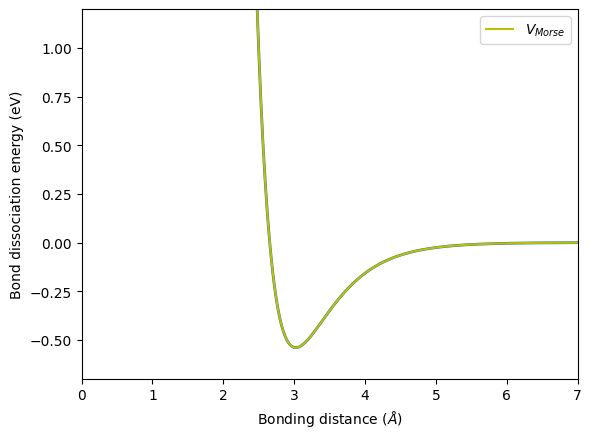

In [3]:
plt.figure(3)

D = 0.54
B = 1.885
R = 3.024

t = np.arange(-5.0,20.0,0.01)
s = D*(np.exp(-2*B*(t-R))-2*np.exp(-B*(t-R)))
line, = plt.plot(t,s,lw=2)

plt.ylim(-0.7,1.2)
plt.xlim(0.0,7.0)

plt.plot(t, s, "-y", label=r'$V_{Morse}$')
plt.legend(loc="upper right")

plt.xlabel("Bonding distance "r'$(\AA)$')
plt.ylabel("Bond dissociation energy (eV)")
plt.show()

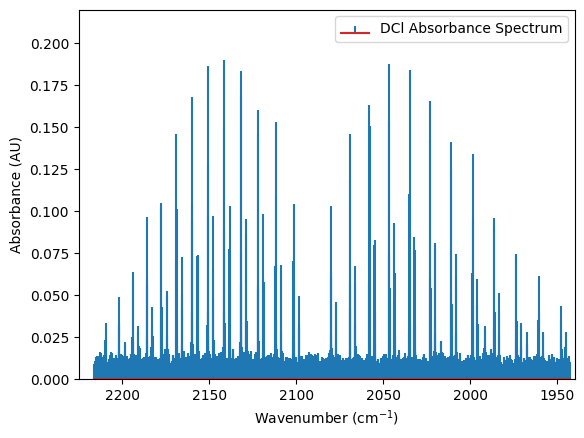

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import csv

wavenumbers = []
absorbances = []

with open('dcl_ir-trans.csv') as csvDataFile:
    csvReader = csv.reader(csvDataFile)
    itersk = iter(csvReader)
    next(itersk)
    for row in itersk:
        wavenumbers.append(float(row[0]))
        absorbances.append(-np.log10(float(row[1])))

plt.figure(2)


plt.ylim(0,0.22)
plt.xlim(2225.0,1940.0)

plt.stem(wavenumbers, absorbances, markerfmt='', label='DCl Absorbance Spectrum')
plt.legend(loc="upper right")

plt.xlabel("Wavenumber (cm" r'$^{-1}$'")")
plt.ylabel("Absorbance (AU)")
plt.show()

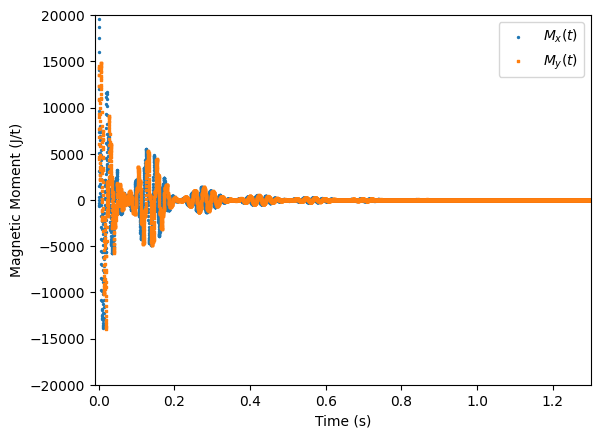

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import csv

times = []
Mx = []
My = []

with open('ethanol_FID_raw.csv') as csvDataFile:
    csvReader = csv.reader(csvDataFile)
    itersk = iter(csvReader)
    next(itersk)
    for row in itersk:
        times.append(float(row[0]))
        Mx.append(float(row[1]))
        My.append(float(row[2]))

plt.figure(1)

plt.ylim(-20000.0,20000.0)
plt.xlim(-0.01,1.3)

plt.scatter(times, Mx, marker='o', label=r'$M_x(t)$', s=2)
plt.scatter(times, My, marker='s', label=r'$M_y(t)$', s=2)
plt.legend(loc="upper right")

plt.xlabel("Time (s)")
plt.ylabel("Magnetic Moment (J/t)")
plt.show()

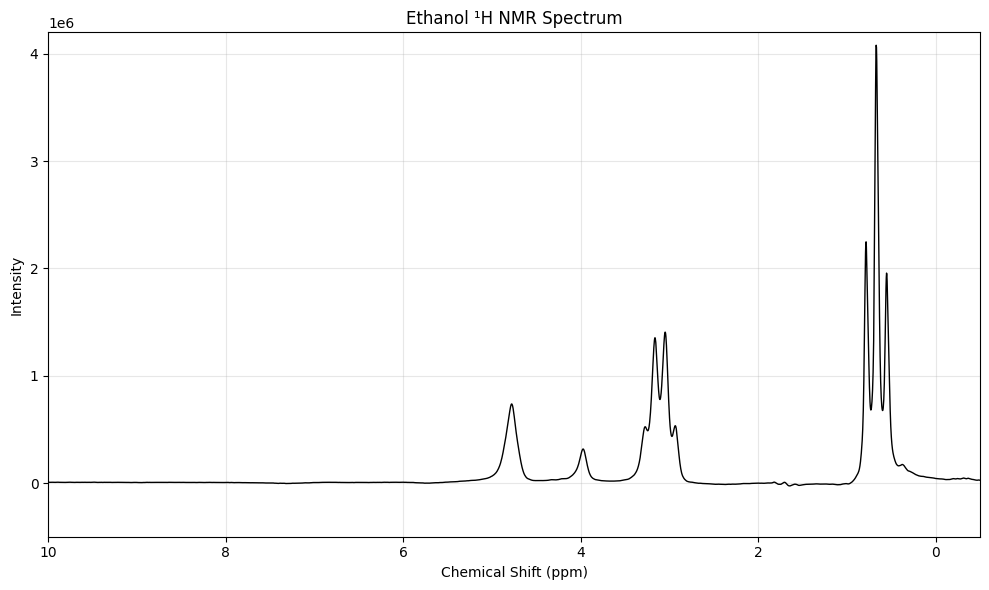

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==== USER PARAMETERS ====
spectrometer_freq_MHz = 60.37137482121646  # your exact value
zero_fill_factor = 4
lb = 0.5  # line broadening in Hz

# Optional chemical shift reference (ppm)
reference_ppm = 0.0   # set if you know TMS or solvent peak

# ==== LOAD DATA ====
data = pd.read_csv('ethanol_FID_raw.csv')

time = data.iloc[:, 0].values
Mx = data.iloc[:, 1].values
My = data.iloc[:, 2].values

# ==== BUILD COMPLEX FID ====
fid = Mx + 1j * My

# ==== SAMPLING INFO ====
dt = time[1] - time[0]
n = len(fid)

# ==== APODIZATION ====
if lb > 0:
    window = np.exp(-lb * np.pi * time)
    fid *= window

# ==== ZERO FILLING ====
n_zf = int(n * zero_fill_factor)
fid_zf = np.zeros(n_zf, dtype=complex)
fid_zf[:n] = fid

# ==== FFT ====
spectrum = np.fft.fft(fid_zf)
spectrum = np.fft.fftshift(spectrum)


# ==== FREQUENCY AXIS ====
freq_Hz = np.fft.fftfreq(n_zf, d=dt)
freq_Hz = np.fft.fftshift(freq_Hz)

# ==== PHASE CORRECTION ====
# Zero-order (p0) and first-order (p1) phase in degrees
p0 = -14.0
p1 = 0.0

# Normalize frequency axis for first-order phase
phi = np.deg2rad(p0 + p1 * (freq_Hz - freq_Hz.mean()) / (freq_Hz.max() - freq_Hz.min()))

spectrum = spectrum * np.exp(1j * phi)


# Convert to ppm
ppm = freq_Hz / spectrometer_freq_MHz + reference_ppm

# ==== PLOT ====
plt.figure(figsize=(10, 6))
plt.plot(ppm, np.real(spectrum), color='black', linewidth=1)

plt.ylim(-0.5e6,4.2e6)
plt.xlim(10.0, -0.5)

plt.xlabel("Chemical Shift (ppm)")
plt.ylabel("Intensity")
plt.title("Ethanol ¹H NMR Spectrum")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()